In [24]:
import pandas as pd
import scanpy as sc
from scipy.io import mmread
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
adata = sc.read_10x_h5("../New_Data/skin_TXK6Z4X_A1/binned_outputs/square_008um/filtered_feature_bc_matrix.h5")
df_barcodes = pd.read_csv("../New_Data/skin_TXK6Z4X_A1/binned_outputs/square_008um/filtered_feature_bc_matrix/barcodes.tsv.gz", sep="\t", header=None)
df_features = pd.read_csv("../New_Data/skin_TXK6Z4X_A1/binned_outputs/square_008um/filtered_feature_bc_matrix/features.tsv.gz", sep="\t", header=None)
df_tissue_positions = pd.read_parquet("../New_Data/skin_TXK6Z4X_A1/binned_outputs/square_008um/spatial/tissue_positions.parquet")


/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [29]:
adata.var_names_make_unique()
umi_counts = adata.to_df()
umi_counts

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
s_008um_00301_00321-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
s_008um_00602_00290-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
s_008um_00515_00112-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
s_008um_00526_00291-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
s_008um_00681_00396-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00653_00166-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_008um_00353_00477-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
s_008um_00797_00672-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_008um_00565_00244-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
df_barcodes

,0
0,s_008um_00301_00321-1
1,s_008um_00602_00290-1
2,s_008um_00515_00112-1
3,s_008um_00526_00291-1
4,s_008um_00681_00396-1
...,...
310113,s_008um_00653_00166-1
310114,s_008um_00353_00477-1
310115,s_008um_00797_00672-1
310116,s_008um_00565_00244-1


In [31]:
df_features

,0,1,2
0,ENSG00000187634,SAMD11,Gene Expression
1,ENSG00000188976,NOC2L,Gene Expression
2,ENSG00000187961,KLHL17,Gene Expression
3,ENSG00000187583,PLEKHN1,Gene Expression
4,ENSG00000187642,PERM1,Gene Expression
...,...,...,...
18080,ENSG00000212907,MT-ND4L,Gene Expression
18081,ENSG00000198886,MT-ND4,Gene Expression
18082,ENSG00000198786,MT-ND5,Gene Expression
18083,ENSG00000198695,MT-ND6,Gene Expression


In [32]:
df_tissue_positions

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,s_008um_00000_00000-1,0,0,0,22505.263073,25072.748986
1,s_008um_00000_00001-1,0,0,1,22505.476012,25056.786425
2,s_008um_00000_00002-1,0,0,2,22505.688951,25040.823864
3,s_008um_00000_00003-1,0,0,3,22505.901890,25024.861303
4,s_008um_00000_00004-1,0,0,4,22506.114830,25008.898743
...,...,...,...,...,...,...
702239,s_008um_00837_00833-1,0,837,833,36043.026674,11954.520977
702240,s_008um_00837_00834-1,0,837,834,36043.239499,11938.558619
702241,s_008um_00837_00835-1,0,837,835,36043.452324,11922.596261
702242,s_008um_00837_00836-1,0,837,836,36043.665149,11906.633904


/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


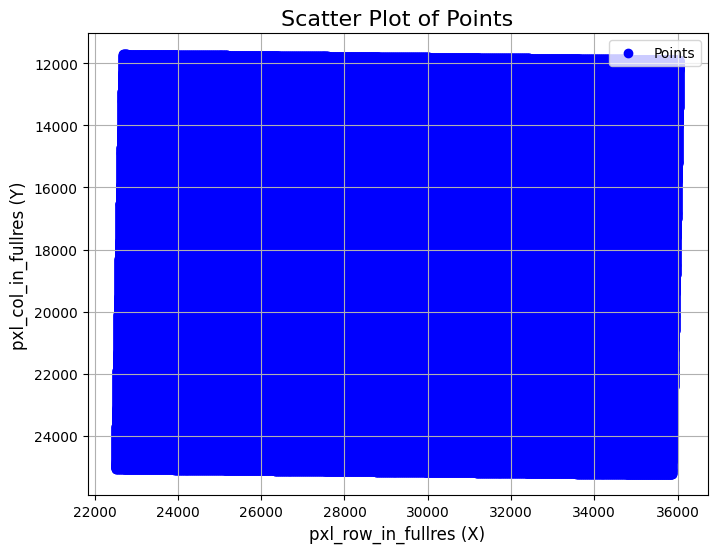

In [33]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_tissue_positions['pxl_row_in_fullres'], df_tissue_positions['pxl_col_in_fullres'], color='blue', label='Points')

# Formatting the plot
plt.title('Scatter Plot of Points', fontsize=16)
plt.xlabel('pxl_row_in_fullres (X)', fontsize=12)
plt.ylabel('pxl_col_in_fullres (Y)', fontsize=12)
plt.gca().invert_yaxis()  # Invert Y-axis if necessary (common for image coordinates)
plt.legend()
plt.grid(True)
plt.show()